# SeaAlert - Notebook 00: Audio & ASR Exploratory Data Analysis

This notebook performs an exploratory data analysis (EDA) on the generated audio files and their ASR transcriptions to ensure data quality and distribution balance.

**Key Analyses:**
1.  **Audio Analysis**: Examines the distribution of audio durations across different distress categories (Distress, Safety, Urgency, Routine).
2.  **ASR Performance**: Analyzes Word Error Rates (WER) for different noise levels (Clean vs. Noisy) to understand the impact of maritime channel noise.
3.  **Visualization**: Plots histograms and boxplots to visualize duration spreads and WER comparisons.
4.  **Sanity Check**: Verifies that the audio generation process produced valid files with expected properties.

**Output:** Visualization plots and summary statistics confirming the dataset's readiness for training.

## Cell 0 - Setup

In [1]:
# Mount Google Drive (Colab)
import sys
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')

# Install dependencies
!pip install -q pandas numpy matplotlib seaborn soundfile librosa jiwer

# Imports
import os
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import soundfile as sf

# Style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

# Project directory
if IN_COLAB:
    PROJECT_DIR = Path("/content/drive/MyDrive/SeaAlert")
else:
    PROJECT_DIR = Path(".").resolve().parent

# Paths
AUDIO_CLEAN_DIR = PROJECT_DIR / "data" / "audio_clean"
AUDIO_NOISY_DIR = PROJECT_DIR / "data" / "audio_noisy"
ASR_DIR = PROJECT_DIR / "data" / "asr"
RESULTS_DIR = PROJECT_DIR / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print(f"PROJECT_DIR: {PROJECT_DIR}")

Mounted at /content/drive
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 34.6 MB/s eta 0:00:00
PROJECT_DIR: /content/drive/MyDrive/SeaAlert


## Cell 1 - Load Audio Index

In [2]:
# Load clean audio index
AUDIO_INDEX_PATH = AUDIO_CLEAN_DIR / "audio_index.csv"

if not AUDIO_INDEX_PATH.exists():
    print(f"WARNING: Audio index not found: {AUDIO_INDEX_PATH}")
    print("Run notebook 02 first.")
    audio_df = None
else:
    audio_df = pd.read_csv(AUDIO_INDEX_PATH)
    print(f"Loaded {len(audio_df)} audio records")
    print(f"Columns: {audio_df.columns.tolist()}")

# Load noisy audio index if exists
NOISY_INDEX_PATH = AUDIO_NOISY_DIR / "noisy_index.csv"
if NOISY_INDEX_PATH.exists():
    noisy_df = pd.read_csv(NOISY_INDEX_PATH)
    print(f"\nLoaded {len(noisy_df)} noisy audio records")
else:
    noisy_df = None
    print("\nNoisy audio index not found (run notebook 03)")

Loaded 1872 audio records
Columns: ['idx', 'wav_path_clean', 'label', 'style', 'scenario_type', 'speaker']

Loaded 1872 noisy audio records


## Cell 2 - Audio Duration Analysis

In [3]:
if audio_df is not None:
    # Get audio file info
    durations = []
    sample_rates = []
    file_sizes = []

    print("Analyzing audio files...")
    for _, row in audio_df.iterrows():
        wav_path = Path(row['wav_path_clean'])
        if wav_path.exists():
            try:
                info = sf.info(str(wav_path))
                durations.append(info.duration)
                sample_rates.append(info.samplerate)
                file_sizes.append(wav_path.stat().st_size / 1024)  # KB
            except:
                durations.append(np.nan)
                sample_rates.append(np.nan)
                file_sizes.append(np.nan)
        else:
            durations.append(np.nan)
            sample_rates.append(np.nan)
            file_sizes.append(np.nan)

    audio_df['duration'] = durations
    audio_df['sample_rate'] = sample_rates
    audio_df['file_size_kb'] = file_sizes

    print(f"\nProcessed {len(audio_df)} files")
    print(f"Missing files: {audio_df['duration'].isna().sum()}")

Analyzing audio files...

Processed 1872 files
Missing files: 0


/tmp/ipython-input-2742894262.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=audio_df, x='label', y='duration', order=label_order,


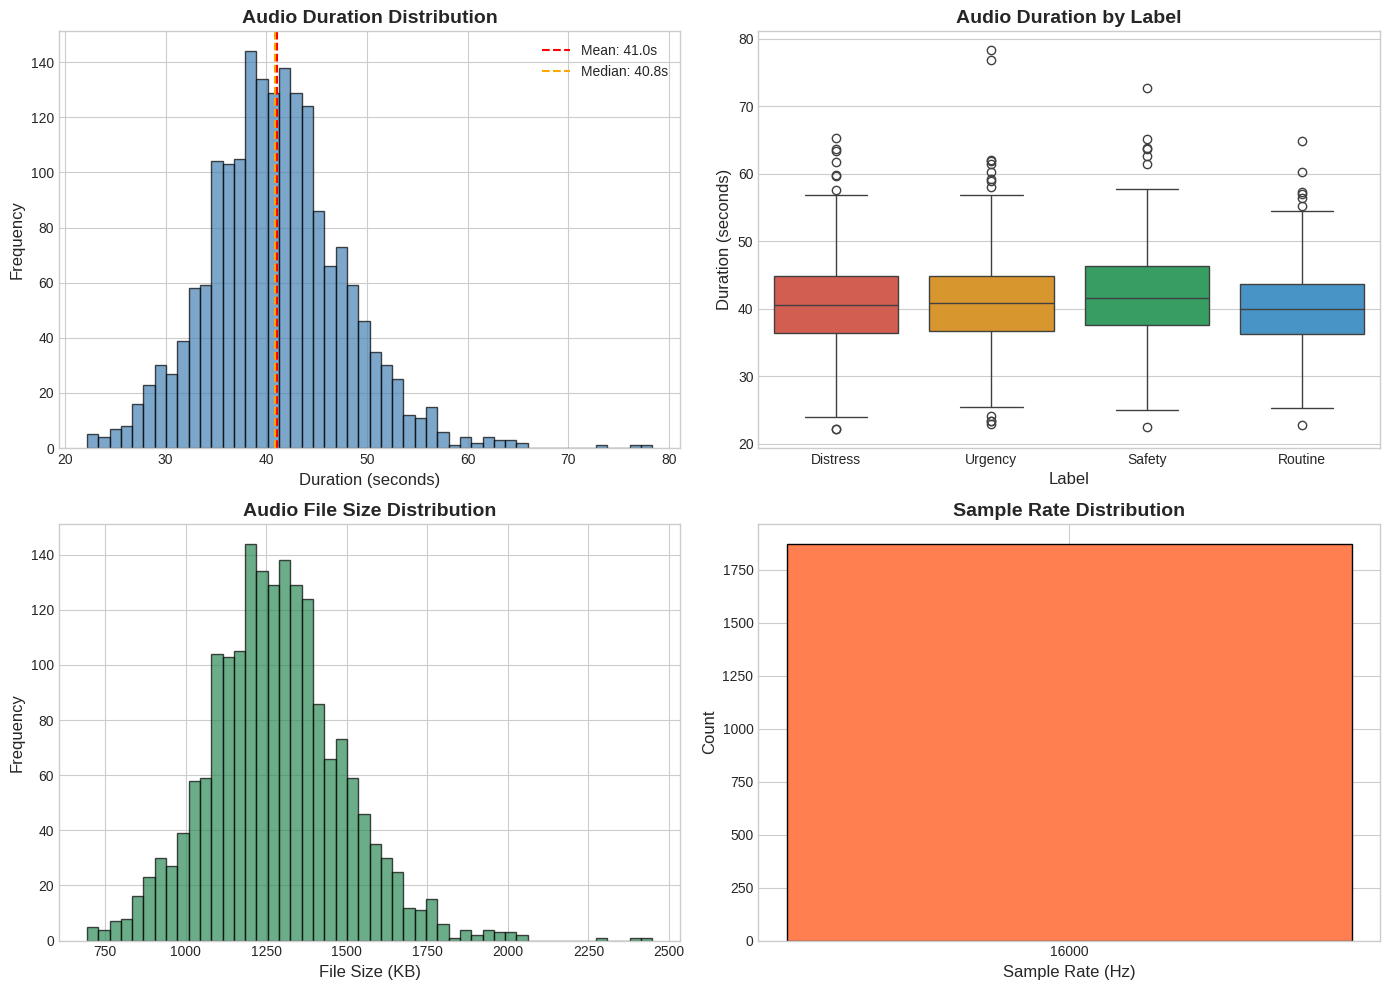


Audio Statistics:
  Duration: min=22.2s, max=78.3s, mean=41.0s
  File size: min=693.2KB, max=2447.7KB, mean=1282.0KB
  Total audio time: 1279.9 minutes
  Total disk space: 2343.7 MB


In [4]:
if audio_df is not None and 'duration' in audio_df.columns:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # Duration distribution
    ax1 = axes[0, 0]
    valid_durations = audio_df['duration'].dropna()
    ax1.hist(valid_durations, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
    ax1.axvline(valid_durations.mean(), color='red', linestyle='--',
                label=f'Mean: {valid_durations.mean():.1f}s')
    ax1.axvline(valid_durations.median(), color='orange', linestyle='--',
                label=f'Median: {valid_durations.median():.1f}s')
    ax1.set_xlabel('Duration (seconds)', fontsize=12)
    ax1.set_ylabel('Frequency', fontsize=12)
    ax1.set_title('Audio Duration Distribution', fontsize=14, fontweight='bold')
    ax1.legend()

    # Duration by label
    ax2 = axes[0, 1]
    label_order = ['Distress', 'Urgency', 'Safety', 'Routine']
    colors = ['#e74c3c', '#f39c12', '#27ae60', '#3498db']
    sns.boxplot(data=audio_df, x='label', y='duration', order=label_order,
                palette=colors, ax=ax2)
    ax2.set_xlabel('Label', fontsize=12)
    ax2.set_ylabel('Duration (seconds)', fontsize=12)
    ax2.set_title('Audio Duration by Label', fontsize=14, fontweight='bold')

    # File size distribution
    ax3 = axes[1, 0]
    valid_sizes = audio_df['file_size_kb'].dropna()
    ax3.hist(valid_sizes, bins=50, color='seagreen', edgecolor='black', alpha=0.7)
    ax3.set_xlabel('File Size (KB)', fontsize=12)
    ax3.set_ylabel('Frequency', fontsize=12)
    ax3.set_title('Audio File Size Distribution', fontsize=14, fontweight='bold')

    # Sample rate check
    ax4 = axes[1, 1]
    sr_counts = audio_df['sample_rate'].value_counts()
    ax4.bar([str(int(sr)) for sr in sr_counts.index], sr_counts.values,
            color='coral', edgecolor='black')
    ax4.set_xlabel('Sample Rate (Hz)', fontsize=12)
    ax4.set_ylabel('Count', fontsize=12)
    ax4.set_title('Sample Rate Distribution', fontsize=14, fontweight='bold')

    plt.tight_layout()
    plt.savefig(RESULTS_DIR / 'eda_audio_duration.png', dpi=150, bbox_inches='tight')
    plt.show()

    # Print stats
    print("\nAudio Statistics:")
    print(f"  Duration: min={valid_durations.min():.1f}s, max={valid_durations.max():.1f}s, mean={valid_durations.mean():.1f}s")
    print(f"  File size: min={valid_sizes.min():.1f}KB, max={valid_sizes.max():.1f}KB, mean={valid_sizes.mean():.1f}KB")
    print(f"  Total audio time: {valid_durations.sum()/60:.1f} minutes")
    print(f"  Total disk space: {valid_sizes.sum()/1024:.1f} MB")

## Cell 3 - Spectrogram Examples

In [5]:
try:
    import librosa
    import librosa.display

    if audio_df is not None:
        # Select one sample per label
        fig, axes = plt.subplots(2, 2, figsize=(14, 10))
        labels = ['Distress', 'Urgency', 'Safety', 'Routine']

        for ax, label in zip(axes.flat, labels):
            label_df = audio_df[audio_df['label'] == label]
            if len(label_df) > 0:
                sample_row = label_df.iloc[0]
                wav_path = sample_row['wav_path_clean']

                if Path(wav_path).exists():
                    y, sr = librosa.load(wav_path, sr=None)
                    D = librosa.amplitude_to_db(np.abs(librosa.stft(y)), ref=np.max)
                    librosa.display.specshow(D, sr=sr, x_axis='time', y_axis='hz', ax=ax)
                    ax.set_title(f'{label} (idx={sample_row["idx"]})', fontsize=12, fontweight='bold')
                else:
                    ax.text(0.5, 0.5, 'File not found', ha='center', va='center')
                    ax.set_title(label, fontsize=12)

        plt.tight_layout()
        plt.savefig(RESULTS_DIR / 'eda_spectrograms.png', dpi=150, bbox_inches='tight')
        plt.show()
except ImportError:
    print("librosa not available for spectrogram analysis")

Output hidden; open in https://colab.research.google.com to view.

## Cell 4 - ASR Transcript Analysis

In [6]:
# Load ASR transcripts
ASR_PATH = ASR_DIR / "asr_transcripts.csv"

if ASR_PATH.exists():
    asr_df = pd.read_csv(ASR_PATH)
    print(f"Loaded {len(asr_df)} ASR transcripts")
    print(f"Columns: {asr_df.columns.tolist()}")
    asr_df.head()
else:
    asr_df = None
    print(f"ASR transcripts not found: {ASR_PATH}")
    print("Run notebook 03 first.")

Loaded 1872 ASR transcripts
Columns: ['idx', 'asr_low', 'asr_med', 'asr_high']


In [7]:
if asr_df is not None:
    # Load original dataset for comparison
    original_df = pd.read_csv(PROJECT_DIR / "data" / "processed" / "02seaalert.csv")

    # Merge original text
    if 'idx' in asr_df.columns:
        merged_df = asr_df.merge(original_df[['idx', 'text', 'label']], on='idx', how='left')
    else:
        merged_df = asr_df.copy()
        merged_df['text'] = original_df['text'].values[:len(asr_df)]
        merged_df['label'] = original_df['label'].values[:len(asr_df)]

    print(f"Merged dataset: {len(merged_df)} rows")
    merged_df.head()

Merged dataset: 1872 rows


## Cell 5 - WER (Word Error Rate) Analysis

In [8]:
if asr_df is not None:
    try:
        from jiwer import wer

        # Calculate WER for each noise level
        noise_levels = ['low', 'med', 'high']
        wer_results = []

        for level in noise_levels:
            asr_col = f'asr_{level}'
            if asr_col in merged_df.columns:
                wers = []
                for _, row in merged_df.iterrows():
                    orig = str(row['text'])
                    trans = str(row[asr_col]) if pd.notna(row[asr_col]) else ''
                    if orig and trans:
                        try:
                            w = wer(orig.lower(), trans.lower())
                            wers.append(w)
                        except:
                            wers.append(np.nan)
                    else:
                        wers.append(np.nan)

                merged_df[f'wer_{level}'] = wers
                avg_wer = np.nanmean(wers)
                wer_results.append({'level': level, 'avg_wer': avg_wer})
                print(f"WER ({level} noise): {avg_wer:.3f} ({avg_wer*100:.1f}%)")

        wer_summary = pd.DataFrame(wer_results)

    except ImportError:
        print("jiwer not available for WER calculation")
        wer_summary = None

WER (low noise): 0.268 (26.8%)
WER (med noise): 0.296 (29.6%)
WER (high noise): 0.362 (36.2%)


/tmp/ipython-input-2927544868.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=merged_df, x='label', y='wer_high', order=label_order,


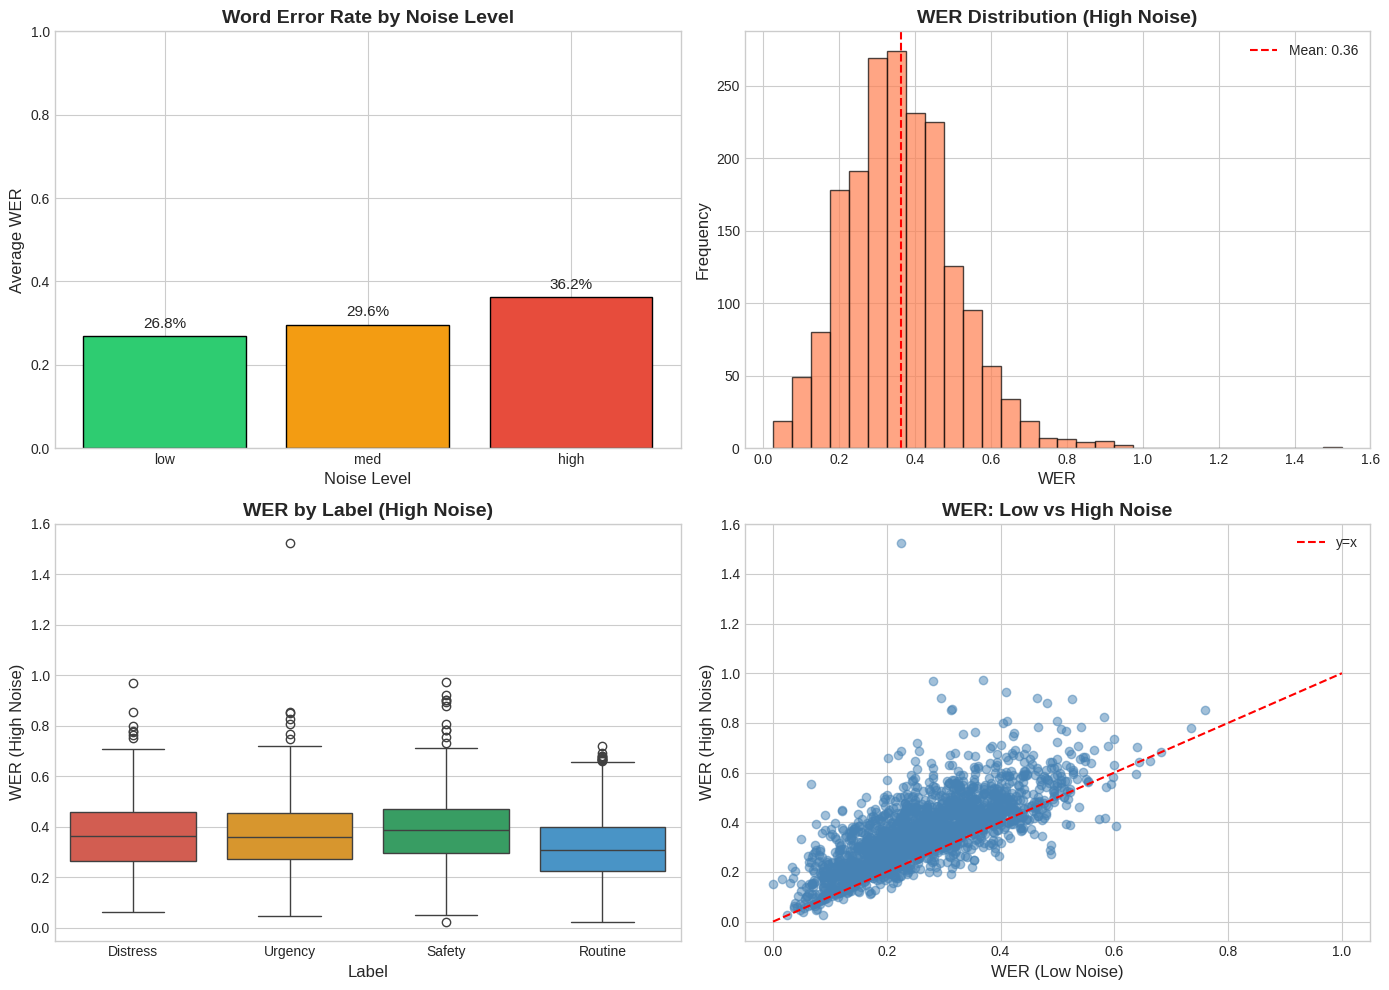

In [9]:
if asr_df is not None and 'wer_low' in merged_df.columns:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # WER by noise level
    ax1 = axes[0, 0]
    wer_cols = [col for col in merged_df.columns if col.startswith('wer_')]
    wer_means = [merged_df[col].mean() for col in wer_cols]
    levels = [col.replace('wer_', '') for col in wer_cols]
    colors = ['#2ecc71', '#f39c12', '#e74c3c']
    bars = ax1.bar(levels, wer_means, color=colors, edgecolor='black')
    ax1.set_xlabel('Noise Level', fontsize=12)
    ax1.set_ylabel('Average WER', fontsize=12)
    ax1.set_title('Word Error Rate by Noise Level', fontsize=14, fontweight='bold')
    ax1.set_ylim(0, 1)
    for bar, val in zip(bars, wer_means):
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                 f'{val:.1%}', ha='center', fontsize=11)

    # WER distribution (high noise)
    ax2 = axes[0, 1]
    ax2.hist(merged_df['wer_high'].dropna(), bins=30, color='coral', edgecolor='black', alpha=0.7)
    ax2.axvline(merged_df['wer_high'].mean(), color='red', linestyle='--',
                label=f'Mean: {merged_df["wer_high"].mean():.2f}')
    ax2.set_xlabel('WER', fontsize=12)
    ax2.set_ylabel('Frequency', fontsize=12)
    ax2.set_title('WER Distribution (High Noise)', fontsize=14, fontweight='bold')
    ax2.legend()

    # WER by label
    ax3 = axes[1, 0]
    label_order = ['Distress', 'Urgency', 'Safety', 'Routine']
    label_colors = ['#e74c3c', '#f39c12', '#27ae60', '#3498db']
    sns.boxplot(data=merged_df, x='label', y='wer_high', order=label_order,
                palette=label_colors, ax=ax3)
    ax3.set_xlabel('Label', fontsize=12)
    ax3.set_ylabel('WER (High Noise)', fontsize=12)
    ax3.set_title('WER by Label (High Noise)', fontsize=14, fontweight='bold')

    # Comparison: low vs high WER
    ax4 = axes[1, 1]
    ax4.scatter(merged_df['wer_low'], merged_df['wer_high'], alpha=0.5, color='steelblue')
    ax4.plot([0, 1], [0, 1], 'r--', label='y=x')
    ax4.set_xlabel('WER (Low Noise)', fontsize=12)
    ax4.set_ylabel('WER (High Noise)', fontsize=12)
    ax4.set_title('WER: Low vs High Noise', fontsize=14, fontweight='bold')
    ax4.legend()

    plt.tight_layout()
    plt.savefig(RESULTS_DIR / 'eda_wer_analysis.png', dpi=150, bbox_inches='tight')
    plt.show()

## Cell 6 - ASR Error Examples

In [10]:
if asr_df is not None and 'wer_high' in merged_df.columns:
    print("=" * 60)
    print("ASR ERROR EXAMPLES")
    print("=" * 60)

    # High WER examples
    print("\n--- HIGH WER EXAMPLES (worst transcriptions) ---")
    high_wer = merged_df.nlargest(3, 'wer_high')
    for i, (_, row) in enumerate(high_wer.iterrows(), 1):
        print(f"\n{i}. WER: {row['wer_high']:.1%}")
        print(f"   Original: {str(row['text'])[:100]}...")
        print(f"   ASR (high): {str(row.get('asr_high', ''))[:100]}...")

    # Low WER examples
    print("\n--- LOW WER EXAMPLES (best transcriptions) ---")
    low_wer = merged_df[merged_df['wer_high'] > 0].nsmallest(3, 'wer_high')
    for i, (_, row) in enumerate(low_wer.iterrows(), 1):
        print(f"\n{i}. WER: {row['wer_high']:.1%}")
        print(f"   Original: {str(row['text'])[:100]}...")
        print(f"   ASR (high): {str(row.get('asr_high', ''))[:100]}...")

ASR ERROR EXAMPLES

--- HIGH WER EXAMPLES (worst transcriptions) ---

1. WER: 152.5%
   Original: Hey there, this is the Sea Breeze, uh, just checking in, you know? Um, we’re currently sitting at ab...
   ASR (high): Hey there, this is the sea breeze, I'm just checking in, you know, I'm recording sitting at about a ...

2. WER: 97.3%
   Original: SECURITE, SECURITE, SECURITE. This is the fishing vessel 'Ocean Catch' relaying a tow request. They ...
   ASR (high): Secure, secure, secure, this is the first time I saw a shortcut to the end of the course.  There can...

3. WER: 96.9%
   Original: This is the fishing vessel Ocean Star relaying a distress call. The vessel Silver Wave, located at L...
   ASR (high): This is the first one I saw as I saw you wearing a distress call.  The last one I saw from the roof,...

--- LOW WER EXAMPLES (best transcriptions) ---

1. WER: 2.5%
   Original: This is a relay from the fishing vessel Sea Harvester. They report a steering failure approximately ..

## Cell 7 - Codeword Preservation Analysis

In [11]:
if asr_df is not None:
    def has_codeword(text):
        """Check if text contains a GMDSS codeword."""
        text = str(text).upper()
        if 'MAYDAY' in text:
            return 'MAYDAY'
        elif 'PAN PAN' in text or 'PAN-PAN' in text:
            return 'PAN PAN'
        elif 'SECURITE' in text:
            return 'SECURITE'
        return 'NONE'

    # Check codeword preservation
    print("=" * 60)
    print("CODEWORD PRESERVATION ANALYSIS")
    print("=" * 60)

    merged_df['orig_cw'] = merged_df['text'].apply(has_codeword)

    for level in ['low', 'med', 'high']:
        asr_col = f'asr_{level}'
        if asr_col in merged_df.columns:
            merged_df[f'asr_cw_{level}'] = merged_df[asr_col].apply(has_codeword)

            # Match rate
            match = (merged_df['orig_cw'] == merged_df[f'asr_cw_{level}']).mean()
            print(f"\n{level.upper()} Noise:")
            print(f"  Codeword preservation rate: {match:.1%}")

            # Confusion matrix
            orig_has = merged_df['orig_cw'] != 'NONE'
            asr_has = merged_df[f'asr_cw_{level}'] != 'NONE'

            tp = (orig_has & asr_has).sum()
            fn = (orig_has & ~asr_has).sum()  # Lost codeword
            fp = (~orig_has & asr_has).sum()  # False codeword
            tn = (~orig_has & ~asr_has).sum()

            print(f"  Preserved codewords: {tp}")
            print(f"  Lost codewords: {fn}")
            print(f"  False codewords: {fp}")

CODEWORD PRESERVATION ANALYSIS

LOW Noise:
  Codeword preservation rate: 75.2%
  Preserved codewords: 192
  Lost codewords: 463
  False codewords: 0

MED Noise:
  Codeword preservation rate: 74.3%
  Preserved codewords: 173
  Lost codewords: 482
  False codewords: 0

HIGH Noise:
  Codeword preservation rate: 72.9%
  Preserved codewords: 147
  Lost codewords: 508
  False codewords: 0


## Cell 8 - Summary

In [12]:
print("\n" + "=" * 60)
print("AUDIO & ASR EDA SUMMARY")
print("=" * 60)

if audio_df is not None and 'duration' in audio_df.columns:
    print("\nAudio Statistics:")
    print(f"  Total files: {len(audio_df)}")
    print(f"  Total duration: {audio_df['duration'].sum()/60:.1f} minutes")
    print(f"  Avg duration: {audio_df['duration'].mean():.1f} seconds")
    print(f"  Total size: {audio_df['file_size_kb'].sum()/1024:.1f} MB")

if asr_df is not None and 'wer_high' in merged_df.columns:
    print("\nASR Statistics:")
    print(f"  Transcriptions: {len(asr_df)}")
    for level in ['low', 'med', 'high']:
        col = f'wer_{level}'
        if col in merged_df.columns:
            print(f"  WER ({level}): {merged_df[col].mean():.1%}")

print("\n" + "=" * 60)
print("EDA COMPLETE")
print("=" * 60)
print(f"\nFigures saved to: {RESULTS_DIR}")
print("  - eda_audio_duration.png")
print("  - eda_spectrograms.png")
print("  - eda_wer_analysis.png")


AUDIO & ASR EDA SUMMARY

Audio Statistics:
  Total files: 1872
  Total duration: 1279.9 minutes
  Avg duration: 41.0 seconds
  Total size: 2343.7 MB

ASR Statistics:
  Transcriptions: 1872
  WER (low): 26.8%
  WER (med): 29.6%
  WER (high): 36.2%

EDA COMPLETE

Figures saved to: /content/drive/MyDrive/SeaAlert/results
  - eda_audio_duration.png
  - eda_spectrograms.png
  - eda_wer_analysis.png
